# Coding Task: Perceptron Learning Algorithm (PLA)

**Your mission:** Implement PLA and watch it learn a linear decision boundary.

## Dataset
- Generate synthetic 2D points with labels +1 or -1 (linearly separable).
- Use a fixed true separating line: `x2 = 0.5*x1 + 1`.

## What you need to do

1. Generate **200 random points** (x1, x2) in range [-5, 5].
2. Visualise the generated data (scatter plot, colour by label).
3. Label points: above the line → +1, below → -1.
4. Split the data into **training (80%)** and **test (20%)**.

In [5]:
# Cell 1: Imports and data generation
import numpy as np
import matplotlib.pyplot as plt

def generate_data(N, true_w, x_range=(-5,5)):
    """
    Generate N random 2D points and label them according to true_w.
    true_w = [w0, w1, w2] defines line: w0 + w1*x1 + w2*x2 = 0
    Returns: X_aug (N x 3) with bias column, y (N,)
    """
    X = np.random.uniform(x_range[0], x_range[1], (N, 2))
    X_aug = np.c_[np.ones(N), X]          # add x0 = 1
    y = np.sign(X_aug @ true_w)
    y[y == 0] = 1                         # no zeros
    return X_aug, y

# True separating line (unknown in real life, here used to generate labels)
true_w = np.array([2.0, 1.0, -2.0])

# Generate large dataset (200 points)
N_total = 200
X_aug, y = generate_data(N_total, true_w)

# Split into train / test (80/20)
split = int(0.8 * N_total)
X_train, y_train = X_aug[:split], y[:split]
X_test, y_test = X_aug[split:], y[split:]

print(f"Training size: {len(y_train)}, Test size: {len(y_test)}")

Training size: 160, Test size: 40


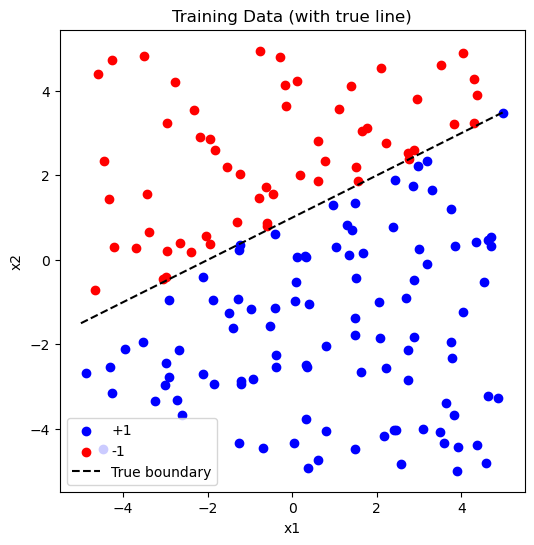

In [7]:
# Cell 2: Visualise the generated data
plt.figure(figsize=(6,6))
plt.scatter(X_train[y_train==1, 1], X_train[y_train==1, 2], c='blue', label='+1')
plt.scatter(X_train[y_train==-1, 1], X_train[y_train==-1, 2], c='red', label='-1')
plt.xlabel('x1'); plt.ylabel('x2')
plt.legend()
plt.title('Training Data (with true line)')

# Plot true separating line (optional)
x_vals = np.linspace(-5,5,100)
# true line: w0 + w1*x1 + w2*x2 = 0  -> x2 = -(w0 + w1*x1)/w2
x2_vals = -(true_w[0] + true_w[1]*x_vals) / true_w[2]
plt.plot(x_vals, x2_vals, 'k--', label='True boundary')
plt.legend()
plt.show()

## What you need to do

4. Implement PLA (train PLA only on the training set):
   - Initialise weights `w = [0, 0, 0]` (bias included).
   - Loop: find first misclassified point, update `w = w + y * x` (where `x` includes `x0=1`).
   - Stop when all training points are correctly classified.
   - Evaluate and print training error and test error.

In [9]:
# Cell 3: PLA implementation (students fill)
def pla(X, y, max_iter=1000):
    w = np.zeros(X.shape[1])               # [w0, w1, w2] = [0,0,0]
    for it in range(max_iter):
        misclassified = False
        for i in range(len(y)):
            if np.sign(X[i] @ w) != y[i]:  # misclassified?
                w = w + y[i] * X[i]        # update rule
                misclassified = True
                break                       # restart from first sample
        if not misclassified:
            return w, it + 1               # converged
    return w, max_iter                      # not converged within max_iter

In [11]:
# Cell 4: Evaluation functions
def predict(w, X):
    """Return predictions ±1 for all rows in X."""
    return np.sign(X @ w)

def error(w, X, y):
    """Fraction of misclassified points."""
    pred = predict(w, X)
    return np.mean(pred != y)

In [13]:
# Cell 5: Train PLA on the training set and evaluate
w_final, iters = pla(X_train, y_train)
train_err = error(w_final, X_train, y_train)
test_err = error(w_final, X_test, y_test)

print(f"Converged in {iters} iterations")
print(f"Training error: {train_err:.4f}")
print(f"Test error: {test_err:.4f}")

Converged in 511 iterations
Training error: 0.0000
Test error: 0.0000


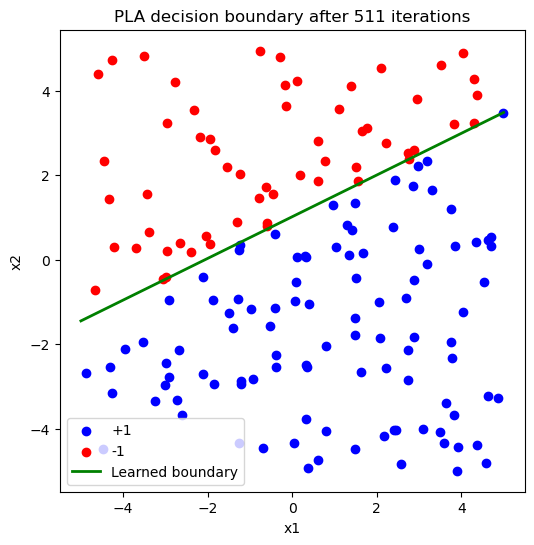

In [15]:
# Cell 6: Plot final decision boundary
plt.figure(figsize=(6,6))
plt.scatter(X_train[y_train==1, 1], X_train[y_train==1, 2], c='blue', label='+1')
plt.scatter(X_train[y_train==-1, 1], X_train[y_train==-1, 2], c='red', label='-1')

# Decision boundary from final weights: w0 + w1*x1 + w2*x2 = 0
x_vals = np.linspace(-5,5,100)
x2_boundary = -(w_final[0] + w_final[1]*x_vals) / w_final[2]
plt.plot(x_vals, x2_boundary, 'g-', linewidth=2, label='Learned boundary')
plt.xlabel('x1'); plt.ylabel('x2')
plt.legend()
plt.title(f'PLA decision boundary after {iters} iterations')
plt.show()

## What you need to do

5. Trying different training sizes [5, 10, 20, 50, 100, 150], and plot learning curves

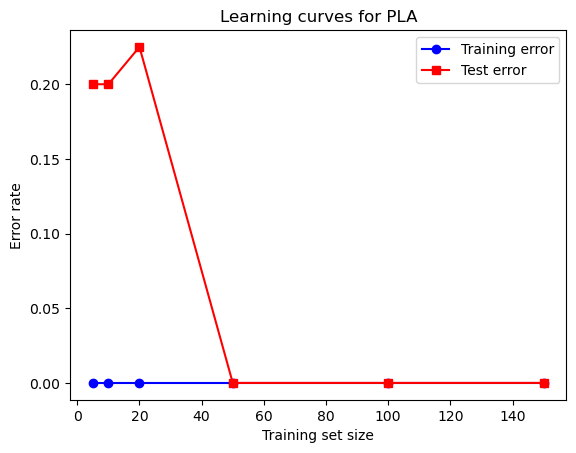

In [17]:
# Cell 7: Vary training set size and plot learning curves
train_sizes = [5, 10, 20, 50, 100, 150]
train_errors = []
test_errors = []

for Ntrain in train_sizes:
    X_sub, y_sub = X_train[:Ntrain], y_train[:Ntrain]
    w, _ = pla(X_sub, y_sub)
    train_errors.append(error(w, X_sub, y_sub))
    test_errors.append(error(w, X_test, y_test))

plt.figure()
plt.plot(train_sizes, train_errors, 'bo-', label='Training error')
plt.plot(train_sizes, test_errors, 'rs-', label='Test error')
plt.xlabel('Training set size')
plt.ylabel('Error rate')
plt.legend()
plt.title('Learning curves for PLA')
plt.show()